This code plots the energy levels of a system defined by the spin hamiltonian, consisting of some combination of the terms below:
$$H = \underbrace{\mu_{B}\times B\times g\times S}_{\textrm{Electronic Zeeman}}+\underbrace{I\times A\times S}_{hyperfine}-\underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As a note notation I refer to the hyperfine and quadrapole as the static hamiltonian with respect to the magnetic field, and the zeeman terms as the dynamic hamiltonian with respect to the magnetic field.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import dask

In [2]:
#spin Operators of Er:Y_2SiO_5:
Espin = 1/2
Ispin = 1/2

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)
excited = spin.cSpinHamiltonian(Espin,Ispin)


Paramaters taken from [Rakonjac Masters Thesis](https://ourarchive.otago.ac.nz/handle/10523/8506)
* Ground pg65
* Excited pg73

In [3]:
#Site 1 Ground Parameters
A_G = np.matrix([[304.8,-252.8,-307.6],[-252.8,778.0,710.2],[-307.6,710.2,616.2]])*1e6*spin.h
Q_G = np.matrix([[10.1,-10.1,-14.0],[-10.1,-6.3,-15.2],[-14.0,-15.6,-3.8]])*1e6*spin.h
g_G = np.matrix([[2.85,-2.98,-3.63],[-2.98,9.00,5.51],[3.63,5.51,5.19]])

#Site 1 Excited Parameters
A_E = np.matrix([[307.9,-327.5,-464.8],[-327.5,607.8,676.7],[-464.8,676.7,980.5]])*1e6*spin.h
Q_E = np.matrix([[56.0,1.66,5.80],[1.66,-53.2,-10.3],[5.80,-10.3,46.4]])*1e6*spin.h
g_E = np.matrix([[2.38,-2.66,-3.63],[-2.66,4.83,5.22],[-3.63,5.22,7.68]])


#Pass our g tensors to the class so they can be used later
ground.setgE(g_G)
excited.setgE(g_E)


As the hyperfine and quadrupole interaction terms are static with the magnetic field we calculate them outside the loop.
If either of these terms aren't needed we don't need to call these functions

In [4]:
#Pre calculate our hyperfine interactions
ground.hyperfineInteraction(A_G)
excited.hyperfineInteraction(A_E)

pass


Sets up operators for optical transition strengths, given by
$$f_{ij}\propto \left|\left<i\right|\hat{O}\left|j\right>\right|^{2}$$
The $\hat{O}$ operators are related to the crystal symmetry and are generated from character tables such as on page 32 of [2010_Powell_Symmetry, Group Theory, and the Physical Properties of Crystals](https://www.dropbox.com/home/QIL_Resources/BookSections?preview=2010_Powell_Symmetry%2C+Group+Theory%2C+and+the+Physical+Properties+of+Crystals.pdf).[^1]

For spin transitions we can use some subset of the dynamic hamiltonian.

[^1]: Link may not work but should be in the dropbox

In [5]:
odim = ground.dim//2
OS_par = np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])
OS_perp = np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])
OS_perp_T = np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])

ang_Er_1 = np.array([205.81,55.33,29.3])*np.pi/180
#ang_Er_1 = np.array([0,0,0])*np.pi/180


Mainloop for each B field value the following is performed:
- The B field is converted from spherical to cartesian coordinates
- We calculate our total hamiltonian consisting of the static hyperfine and/or quadrapole and the dynamic zeeman terms.
- We calculate the eigenvalues and eigenvectors of the hamiltonian, converting the eigenvalues to frequencies.
- We calculate the transition strength between each energy level based on the eigenvectors of the excited and ground states
- We calculate the spin transition probabilities based on the dynamic hamiltonian.

In [6]:
#setup the loop, here it is easier to run the loop outside of the class
theta,phi = spin.eulerToSphere(ang_Er_1,str='ZXZ')
#theta=0
#phi=0


#thetas = [theta]
thetas =np.linspace(0,np.pi/2,10)
phis =np.linspace(0,np.pi/2,10)
#phis = [phi]
Bs=np.linspace(0,40E-3,10)
#Bs = np.logspace(-5,0,5000)
#Bs = [75E-3]
#Bs=[0]


#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim)),dtype = np.csingle)
FreqE = np.zeros((len(thetas),len(phis),len(Bs),int(excited.dim)),dtype = np.csingle)
OS = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)
OS_SG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim),3),dtype = np.csingle)
OS_SE = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim),3),dtype = np.csingle)
CS_G = ground.initSweep(thetas,phis,Bs,ground.dim)
CS_E = excited.initSweep(thetas,phis,Bs,ground.dim)

Bac = np.matrix([0,0,1]).T
BC = np.eye(3)

B,T,P=np.meshgrid(Bs,thetas,phis)
coor = np.vstack([T.ravel(),P.ravel()])

import timeit

#timeit.timeit(lambda : spin.sphereUnit(coor.T),number=10000)
#%timeit 
Bfields=spin.sphereUnit(coor.T)
print(Bfields.shape)


(1000, 3)


In [7]:
#@dask.delayed(nout=7)
def loopfunc(B):

    FreqG,VG,OS_SG,CS_G=stateFunc(ground,B)#dask.delayed(stateFunc)(ground,B)
    FreqE,VE,OS_SE,CS_E=stateFunc(ground,B)#dask.delayed(stateFunc)(excited,B)
    OS = dask.delayed(spin.TransitionStrength)(VG,VE,OS_par,ground.dim)
    
    return FreqE,FreqG,OS,OS_SG,OS_SE,CS_G,CS_E

@dask.delayed(nout=4)
def stateFunc(state,B):
    #Calculate our hamiltonian at this B Field
    H = state.H+state.electronicZeeman(B)
    #get the eigen frequencies and vectors at this B field
    F,V = state.getEigFreq(H)
    
    for l in range(3):
        #print(l)
        OS_S=state.firstOrderEnergySensitivity(V,state.electronicZeeman(BC[:,l])/spin.muB)*spin.muB
    OS_S=0    
    
    A = lambda B: state.electronicZeeman(B)
    CS=ground.curvatureCalculationAlt(A,BC,V,F,indiv=False)
    #CS=0
    return F,V,OS_S,CS

# @dask.delayed(nout=7)
# def unpack(H):
    


#our loop
def loop():
    for i in range(len(thetas)):
        for j in range(len(phis)):
            for k in range(len(Bs)):
                #convert spherical Magnetic field to cartesian coords.
                B =spin.sphereCart(Bs[k],thetas[i],phis[j])
                #Calculate our hamiltonian at this B Field
                HG = ground.H+ground.electronicZeeman(B)
                #get the eigen frequencies and vectors at this B field
                FG,VG = ground.getEigFreq(HG)
                FreqG[i,j,k,:]=FG
                #As above for excited state
                HE = excited.H+excited.electronicZeeman(B)
                FE,VE = excited.getEigFreq(HE)
                FreqE[i,j,k,:]=FE
                #calculate all transition strengths
                    #the optical version takes two sets of eigenvectors and an operator
                OS[i,j,k,:] = spin.TransitionStrength(VG,VE,OS_par,ground.dim)
                    #the spin version is tied to the class taking only one set of eigen values, and a hamiltonian operator


                for l in range(3):
                    #print(l)
                    OS_SG[i,j,k,:,l]=ground.firstOrderEnergySensitivity(VG,ground.electronicZeeman(BC[:,l])/spin.muB)*spin.muB
                    OS_SE[i,j,k,:,l]=excited.firstOrderEnergySensitivity(VE,excited.electronicZeeman(BC[:,l])/spin.muB)*spin.muB

                A = lambda B: ground.electronicZeeman(B)
                #print(VG.shape,FG.shape)
                CS_G[i,j,k,:]=ground.curvatureCalculationAlt(A,BC,VG,FG,indiv=True)
                CS_E[i,j,k,:]=ground.curvatureCalculationAlt(A,BC,VE,FE,indiv=True)
            

#%timeit 
#loop()
#Bs = phis

In [8]:
#%%timeit
test=[]
for i in range(Bfields.shape[0]):
    #print(np.matrix(Bfields[i,:]))
    B = Bfields[i,:].T
    temp=loopfunc(B)#dask.delayed(loopfunc)(B)
    test.append(temp)
#HH=dask.compute(test)



In [9]:
test=[]
for i in range(Bfields.shape[0]):
    #print(np.matrix(Bfields[i,:]))
    B = Bfields[i,:].T
    temp=loopfunc(B)#dask.delayed(loopfunc)(B)
    test.append(temp)
#HH=np.array(dask.compute(test))
#dask.visualize(test)
#print(test)
#print(HH[0,:,0])

In [10]:

B=Bfields[0,:].T
HG = ground.H+ground.electronicZeeman(B)
#get the eigen frequencies and vectors at this B field
FG,VG = ground.getEigFreq(HG)
A = lambda B: ground.electronicZeeman(B)
#print(VG.shape,FG.shape)
#print(VG)
#print(VG[:,0])

print("Naive ",ground.curvatureCalculationNaive(A,BC,VG,FG))
print("Orig ",ground.curvatureCalculationAlt(A,BC,VG,FG,indiv=True))


[[ 1.03606462e-37-4.62089322e-37j -1.28509841e-37-4.53475130e-37j
   3.45936288e-37-6.39282898e-37j -3.33622204e-37-5.98880152e-37j]]
(5.861538118483977e-24+3.766623759968609e-41j)
(5.943901435760996e-24+4.6139659465922456e-40j)
(-5.943611947710202e-24-5.13075932003695e-40j)
(-5.861827606534771e-24+1.401309974478438e-41j)
Naive  [ 31.92509151  32.42246918 -32.41432011 -31.92092187]
Orig  [-31.92509151 -32.42246918  32.41432011  31.92092187]


c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:338: RuntimeWarning: invalid value encountered in true_divide
  pdbn=lambda A,B: np.nan_to_num((((V.H)@A@V)@((V.H)@B@V)/Ed),posinf=0,nan=0,neginf=0)
c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:336: RuntimeWarning: invalid value encountered in true_divide
  pdb=lambda A,B,n: np.trace(np.nan_to_num(((V.H)@A@V[:,n])@((V[:,n].H)@B@V)/(E[n]-E),posinf=0,nan=0,neginf=0))
c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:285: RuntimeWarning: divide by zero encountered in true_divide
  pdB = lambda i,j,H : ((V[:,i].H)@H@V[:,j])/(np.sqrt(np.abs(E[i]-E[j])))
c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:285: RuntimeWarning: invalid value encountered in true_divide
  pdB = lambda i,j,H : ((V[:,i].H)

In [11]:

%timeit ground.curvatureCalculationNaive(A,BC,VG,FG)
%timeit ground.curvatureCalculationAlt(A,BC,VG,FG,indiv=True)

#%timeit ground.curvatureCalculationAlt(A,BC,VG,FG)
                

[[ 1.03606462e-37-4.62089322e-37j -1.28509841e-37-4.53475130e-37j
   3.45936288e-37-6.39282898e-37j -3.33622204e-37-5.98880152e-37j]]
(5.861538118483977e-24+3.766623759968609e-41j)
(5.943901435760996e-24+4.6139659465922456e-40j)
(-5.943611947710202e-24-5.13075932003695e-40j)
(-5.861827606534771e-24+1.401309974478438e-41j)
[[ 1.03606462e-37-4.62089322e-37j -1.28509841e-37-4.53475130e-37j
   3.45936288e-37-6.39282898e-37j -3.33622204e-37-5.98880152e-37j]]
(5.861538118483977e-24+3.766623759968609e-41j)
(5.943901435760996e-24+4.6139659465922456e-40j)
(-5.943611947710202e-24-5.13075932003695e-40j)
(-5.861827606534771e-24+1.401309974478438e-41j)
[[ 1.03606462e-37-4.62089322e-37j -1.28509841e-37-4.53475130e-37j
   3.45936288e-37-6.39282898e-37j -3.33622204e-37-5.98880152e-37j]]
(5.861538118483977e-24+3.766623759968609e-41j)
(5.943901435760996e-24+4.6139659465922456e-40j)
(-5.943611947710202e-24-5.13075932003695e-40j)
(-5.861827606534771e-24+1.401309974478438e-41j)
[[ 1.03606462e-37-4.62089322

Plotting of energy levels for both the ground and excited state.

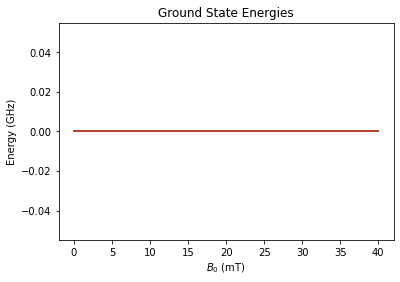

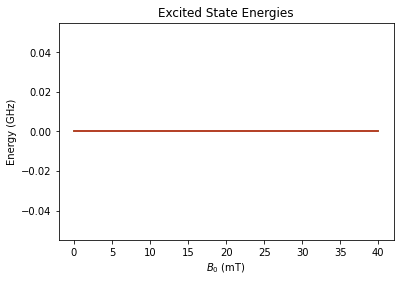

In [12]:

#Plot our energy levels
plt.plot(Bs*1E3,np.squeeze(np.real(FreqG[0,0,:,:])))
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()
plt.plot(Bs*1E3,np.squeeze(np.real(FreqE[0,0,:,:])))
plt.title("Excited State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()